# Boletín 7: Capítulos 3.3 y 3.4
## Validación, Generalización y Métricas de Evaluación

**Objetivo:** Practicar la validación correcta de modelos (evitando overfitting y data leakage) y aprender a calcular e interpretar las métricas de evaluación adecuadas según el tipo de problema.

**Instrucciones:**
- 10 ejercicios ordenados por dificultad
- 🟢 = Básico | 🟡 = Intermedio | 🔴 = Avanzado
---

In [2]:
# Ejecuta esta celda PRIMERO para cargar todas las librerías necesarias
# colores
rojo = '\033[91m'
verde = '\033[92m'
azul = '\033[94m'
magenta = '\033[95m'
amarillo = '\033[93m'
rosa = '\033[38;5;200m'
turquesa = '\033[38;5;44m'
azul_marino = '\33[38;5;67m'
lima = '\33[38;5;46m'
reset = '\033[0m'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression, load_iris
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV, learning_curve)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score,
                             mean_absolute_error, mean_squared_error, r2_score)

np.random.seed(42)
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 🟢 Ejercicio 1: Reconocer overfitting y underfitting a partir de métricas

Un compañero ha entrenado 3 modelos distintos sobre el mismo dataset y te muestra los resultados en train y en test. Tu tarea es **diagnosticar** cada modelo.

A continuación tienes los resultados de los 3 modelos. Para cada uno:

1. **Indica** si el modelo sufre **overfitting**, **underfitting** o tiene **buena generalización**. Justifica tu respuesta en 1-2 frases.
2. **Propón** una acción concreta para mejorar cada modelo problemático (por ejemplo: "usar un modelo más complejo", "añadir regularización", "conseguir más datos", etc.).

| Modelo | Accuracy en Train | Accuracy en Test |
|--------|-------------------|------------------|
| A      | 99.8%             | 62.3%            |
| B      | 58.1%             | 55.7%            |
| C      | 91.2%             | 89.5%            |

Responde con `print()` en la celda de abajo.

In [5]:
# Escribe aquí tu diagnóstico para cada modelo (A, B y C)
# Mi diagnóstico siguiendo los apuntes de la Unidad 3.3

print(f"\n{turquesa}Modelo A --> Overfitting:{reset}{lima} Gap muy alto entre train y test.{reset}{turquesa} Acción:{reset}{lima} Aplicar regularización.{reset}")
print(f"{turquesa}Modelo B --> Underfitting:{reset}{lima} Error alto en ambos conjuntos por falta de complejidad.{reset}{turquesa} Acción:{reset}{lima} Usar un modelo más complejo.{reset}")
print(f"{turquesa}Modelo C --> Buena generalización:{reset}{lima} El gap es mínimo y el accuracy es alto.{reset}{turquesa} Acción:{reset}{lima} Ninguna.{reset}")


Modelo A --> Overfitting: Gap muy alto entre train y test. Acción: Aplicar regularización.
Modelo B --> Underfitting: Error alto en ambos conjuntos por falta de complejidad. Acción: Usar un modelo más complejo.
Modelo C --> Buena generalización: El gap es mínimo y el accuracy es alto. Acción: Ninguna.


## 🟢 Ejercicio 2: División train/test con stratify

En este ejercicio vas a comprobar por qué es importante usar `stratify` cuando las clases están desbalanceadas.

**Pasos a seguir:**

1. Genera un dataset desbalanceado ejecutando el código de la celda de abajo (ya está escrito).
2. Haz un `train_test_split` con `test_size=0.3` y `random_state=42` **SIN** usar `stratify`. Imprime cuántas muestras de cada clase hay en train y en test usando `np.unique(y_train, return_counts=True)`.
3. Haz otro `train_test_split` con los mismos parámetros **PERO** añadiendo `stratify=y`. Imprime las mismas cuentas.
4. **Responde**: ¿En cuál de los dos splits las proporciones de las clases se mantienen mejor respecto al dataset original? ¿Por qué es importante esto en clasificación?

In [32]:
# Dataset desbalanceado (NO modificar esta línea)
X, y = make_classification(n_samples=300, n_features=5, n_classes=2,
                           weights=[0.85, 0.15], random_state=42)

# Comprueba la distribución original
print(f"\n{azul}Distribución original:{reset}", np.unique(y, return_counts=True))

# --- Paso 2: Split SIN stratify ---
# Tu código aquí
X_train_sin, X_test_sin, y_train_sin, y_test_sin = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\n{turquesa}SIN stratify - Train:{reset}", np.unique(y_train_sin, return_counts=True))
print(f"{turquesa}SIN stratify - Test:{reset}", np.unique(y_test_sin, return_counts=True))

# --- Paso 3: Split CON stratify ---
# Tu código aquí
X_train_con, X_test_con, y_train_con, y_test_con = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\n{turquesa}CON stratify - Train:{reset}", np.unique(y_train_con, return_counts=True))
print(f"{turquesa}CON stratify - Test:{reset}", np.unique(y_test_con, return_counts=True))

# --- Paso 4: Responde ---
print(f"{azul}\nRESPUESTA{reset}")
print(f"{lima}- Las proporciones se mantienen mucho mejor en el split con 'stratify=y' porque")
print(f"  fuerza a que el reparto sea igual al original.")
print(f"- Es vital en clasificación para evitar sesgos y asegurar que el modelo vea") 
print(f"  suficientes ejemplos de la clase minoritaria en ambos conjuntos.{reset}")


Distribución original: (array([0, 1]), array([254,  46]))

SIN stratify - Train: (array([0, 1]), array([175,  35]))
SIN stratify - Test: (array([0, 1]), array([79, 11]))

CON stratify - Train: (array([0, 1]), array([178,  32]))
CON stratify - Test: (array([0, 1]), array([76, 14]))

RESPUESTA
- Las proporciones se mantienen mucho mejor en el split con 'stratify=y' porque
  fuerza a que el reparto sea igual al original.
- Es vital en clasificación para evitar sesgos y asegurar que el modelo vea
  suficientes ejemplos de la clase minoritaria en ambos conjuntos.


## 🟡 Ejercicio 3: Pipeline vs enfoque manual (data leakage con StandardScaler)

En este ejercicio vas a ver un caso **real** de data leakage al preprocesar datos. `StandardScaler` **calcula estadísticos** (media y desviación típica) a partir de los datos — y si los calcula sobre todo el dataset **incluyendo el test**, está "filtrando" información del test al entrenamiento.

**Contexto:** Tienes un dataset de regresión y quieres aplicar `StandardScaler` + `Ridge` (modelo lineal regularizado).

**Pasos a seguir:**

### Parte A — Enfoque INCORRECTO (data leakage real)
1. Con el dataset generado abajo, aplica `StandardScaler()` a **TODO** `X` usando `fit_transform`. Esto calcula la media y std con los 200 datos.
2. **Después** haz el `train_test_split(test_size=0.3, random_state=42, shuffle=False)` sobre los datos ya escalados.
3. Entrena un `Ridge(alpha=20.0)` y calcula el **RMSE** en test. Imprímelo.

### Parte B — Enfoque CORRECTO (con Pipeline)
4. Haz **primero** el `train_test_split(test_size=0.3, random_state=42, shuffle=False)` sobre el `X` original (sin escalar).
5. Crea un `Pipeline` con dos pasos: `('scaler', StandardScaler())` y `('ridge', Ridge(alpha=20.0))`.
6. Entrena el Pipeline con `X_train, y_train` y calcula el **RMSE** en test. Imprímelo.

### Parte C — Reflexión
7. **Responde**: ¿Por qué el enfoque A produce data leakage real? ¿Qué información del test se ha "filtrado" al modelo?

In [34]:
from sklearn.preprocessing import StandardScaler

# Dataset de regresión (NO modificar la base)
X, y = make_regression(n_samples=200, n_features=3, noise=15, random_state=42)

# Cambio suave en la distribución del tramo final (test) para que se note el efecto
X[140:, 0] = X[140:, 0] * 2.0 + 1.0

# --- Parte A: Enfoque INCORRECTO (data leakage) ---
# Aplica StandardScaler a TODO X antes del split
# Tu código aquí
scaler_mal = StandardScaler()
X_scaled_mal = scaler_mal.fit_transform(X)

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_scaled_mal, y, test_size=0.3, random_state=42, shuffle=False)

modelo_A = Ridge(alpha=20.0)
modelo_A.fit(X_train_A, y_train_A)
rmse_A = np.sqrt(mean_squared_error(y_test_A, modelo_A.predict(X_test_A)))
print(f"\n{turquesa}RMSE enfoque A (Incorrecto):{reset}{magenta} {rmse_A:.4f}{reset}")

# --- Parte B: Enfoque CORRECTO (Pipeline) ---
# Haz el split primero, luego usa Pipeline con StandardScaler
# Tu código aquí
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=20.0))
])

pipeline.fit(X_train_B, y_train_B)
rmse_B = np.sqrt(mean_squared_error(y_test_B, pipeline.predict(X_test_B)))
print(f"{turquesa}RMSE enfoque B (Pipeline):{reset}{magenta} {rmse_B:.4f}{reset}")


# --- Parte C: Responde ---
print(f"{azul}\nRESPUESTA{reset}")
print(f"{lima}- El enfoque A produce data leakage porque calcula la media y la desviación típica") 
print(f"  usando también los datos de test.")
print(f"- Se ha 'filtrado' información sobre la distribución del test (el escalado de los") 
print(f"  datos finales) que el modelo no debería conocer al entrenar.{reset}")


RMSE enfoque A (Incorrecto): 69.2936
RMSE enfoque B (Pipeline): 75.6397

RESPUESTA
- El enfoque A produce data leakage porque calcula la media y la desviación típica
  usando también los datos de test.
- Se ha 'filtrado' información sobre la distribución del test (el escalado de los
  datos finales) que el modelo no debería conocer al entrenar.


## 🟡 Ejercicio 4: Validación cruzada (Cross-Validation)

En este ejercicio vas a comparar la evaluación de un modelo con un **único split** frente a **validación cruzada con 5 folds**.

**Pasos a seguir:**

1. Con el dataset generado abajo, haz un `train_test_split(test_size=0.2, random_state=42, stratify=y)`. Entrena un `LogisticRegression(max_iter=1000, random_state=42)` y calcula la accuracy en test. Imprímela.
2. Ahora, usa `cross_val_score` con el **mismo modelo** sobre el dataset completo (`X, y`) y `cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`. Imprime los 5 scores individuales, la **media** y la **desviación estándar**.
3. **Responde**: ¿Cuál de las dos evaluaciones es más fiable y por qué? ¿Qué te dice la desviación estándar de los folds?

In [35]:
# Dataset de clasificación (NO modificar)
X, y = make_classification(n_samples=500, n_features=10, n_informative=5,
                           n_redundant=2, random_state=42)

# --- Paso 1: Evaluación con un único split ---
# Tu código aquí
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_train, y_train)
print(f"\n{turquesa}Accuracy único split:{reset}{magenta} {modelo_log.score(X_test, y_test):.4f}{reset}")

# --- Paso 2: Evaluación con cross-validation (5-Fold) ---
# Tu código aquí
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo_log, X, y, cv=skf)
print(f"\n{turquesa}Scores por fold:{reset}{magenta} {scores}{reset}")
print(f"{turquesa}Media:{reset}{magenta} {scores.mean():.4f}{reset}")
print(f"{turquesa}Desviación estándar:{reset}{magenta} {scores.std():.4f}{reset}")

# --- Paso 3: Responde ---
print(f"{azul}\nRESPUESTA{reset}")
print(f"{lima}- La CV es más fiable porque usa todos los datos para validar y no depende de la")
print(f"  'suerte' de un único reparto aleatorio.")
print(f"- La desviación estándar indica la estabilidad: si es baja, el modelo es robusto y") 
print(f"  no es sensible a cambios en los datos de train.{reset}")


Accuracy único split: 0.8400

Scores por fold: [0.82 0.89 0.81 0.88 0.81]
Media: 0.8420
Desviación estándar: 0.0354

RESPUESTA
- La CV es más fiable porque usa todos los datos para validar y no depende de la
  'suerte' de un único reparto aleatorio.
- La desviación estándar indica la estabilidad: si es baja, el modelo es robusto y
  no es sensible a cambios en los datos de train.


## 🟡 Ejercicio 5: Búsqueda de hiperparámetros con GridSearchCV

En este ejercicio vas a usar `GridSearchCV` dentro de un `Pipeline` para buscar el mejor valor del hiperparámetro `C` de una `LogisticRegression`.

**Pasos a seguir:**

1. Con el dataset generado abajo, haz un `train_test_split(test_size=0.2, random_state=42, stratify=y)`.
2. Crea un `Pipeline` con dos pasos: `('scaler', StandardScaler())` y `('clf', LogisticRegression(max_iter=1000, random_state=42))`.
3. Define un diccionario de hiperparámetros a probar: `{'clf__C': [0.01, 0.1, 1, 10, 100]}`. Recuerda: dentro de un Pipeline, el nombre del parámetro se forma como `'nombre_paso__nombre_parametro'`.
4. Crea un `GridSearchCV` con el Pipeline, el diccionario de hiperparámetros, `cv=5` y `scoring='accuracy'`. Entrénalo con `X_train, y_train`.
5. Imprime: el **mejor valor de C** (`grid.best_params_`), el **mejor score en validación** (`grid.best_score_`), y la **accuracy en test** usando `grid.score(X_test, y_test)`.
6. **Responde**: ¿Por qué es importante que el `StandardScaler` esté dentro del Pipeline y no fuera?

In [36]:
# Dataset de clasificación (NO modificar)
X, y = make_classification(n_samples=600, n_features=10, n_informative=6,
                           n_redundant=2, random_state=42)

# --- Paso 1: Split ---
# Tu código aquí
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Pasos 2-4: Pipeline + GridSearchCV ---
# Tu código aquí
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {'clf__C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# --- Paso 5: Resultados ---
# Tu código aquí
print(f"\n{turquesa}Mejor valor de C:{reset}{magenta} {grid.best_params_}{reset}")
print(f"{turquesa}Mejor score en validación (CV):{reset}{magenta} {grid.best_score_:.4f}{reset}")
print(f"{turquesa}Accuracy final en test:{reset}{magenta} {grid.score(X_test, y_test):.4f}{reset}")

# --- Paso 6: Responde ---
print(f"{azul}\nRESPUESTA{reset}")
print(f"{lima}- Es fundamental que el StandardScaler esté dentro del Pipeline para que el escalado") 
print(f"  se repita correctamente en cada fold de la validación cruzada.")
print(f"- Si estuviera fuera, estaríamos escalando con información de todo el train antes del") 
print(f"  CV, provocando de nuevo data leakage interno.{reset}")


Mejor valor de C: {'clf__C': 0.1}
Mejor score en validación (CV): 0.8292
Accuracy final en test: 0.8500

RESPUESTA
- Es fundamental que el StandardScaler esté dentro del Pipeline para que el escalado
  se repita correctamente en cada fold de la validación cruzada.
- Si estuviera fuera, estaríamos escalando con información de todo el train antes del
  CV, provocando de nuevo data leakage interno.


## 🟡 Ejercicio 6: Matriz de confusión — construir e interpretar

En este ejercicio vas a construir una matriz de confusión a partir de predicciones ya hechas y a interpretar cada celda.

**Contexto:** Un modelo de detección de enfermedades ha evaluado a 20 pacientes. Abajo tienes las etiquetas reales (`y_real`) y las predicciones del modelo (`y_pred`), donde `1 = enfermo` y `0 = sano`.

**Pasos a seguir:**

1. Calcula la matriz de confusión con `confusion_matrix(y_real, y_pred)`. Imprímela.
2. Extrae los 4 valores individuales (TN, FP, FN, TP) usando `cm.ravel()` e imprime cada uno con su significado. Por ejemplo: `"TP = 5 → 5 enfermos detectados correctamente"`.
3. Visualiza la matriz de confusión con `ConfusionMatrixDisplay`. Usa `display_labels=['Sano', 'Enfermo']`.
4. **Responde**: En este contexto médico, ¿cuál es el error más peligroso, un FP (diagnosticar como enfermo a alguien sano) o un FN (diagnosticar como sano a alguien enfermo)? ¿Por qué?

Matriz de confusión
[[12  1]
 [ 2  5]]

TN = 12 --> Personas sanas identificadas correctamente
FP = 1 --> Personas sanas diagnosticadas como enfermas (Falsas alarmas)
FN = 2 --> Personas enfermas que el modelo no detectó
TP = 5 --> Personas enfermas detectadas correctamente

RESPUESTA
- En este contexto médico, el error más peligroso es el Falso Negativo (FN).
- Es crítico porque significa enviar a casa a alguien enfermo pensando que está
  sano, perdiendo la oportunidad de tratarlo a tiempo.


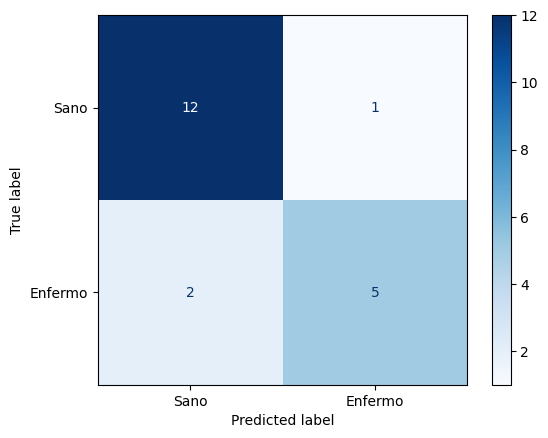

In [29]:
# Datos del modelo de detección de enfermedades (NO modificar)
# 1 = enfermo, 0 = sano
y_real = np.array([0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1])
y_pred = np.array([0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1])

# --- Paso 1: Matriz de confusión ---
# Tu código aquí
cm = confusion_matrix(y_real, y_pred)
print(f"{turquesa}Matriz de confusión{reset}")
print(cm)

# --- Paso 2: Extraer TN, FP, FN, TP ---
# Tu código aquí
tn, fp, fn, tp = cm.ravel()
print(f"\n{turquesa}TN = {tn} -->{reset}{magenta} Personas sanas identificadas correctamente{reset}")
print(f"{turquesa}FP = {fp} -->{reset}{magenta} Personas sanas diagnosticadas como enfermas (Falsas alarmas){reset}")
print(f"{turquesa}FN = {fn} -->{reset}{magenta} Personas enfermas que el modelo no detectó{reset}")
print(f"{turquesa}TP = {tp} -->{reset}{magenta} Personas enfermas detectadas correctamente{reset}")

# --- Paso 3: Visualización ---
# Tu código aquí
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Enfermo'])
disp.plot(cmap='Blues')

# --- Paso 4: Responde ---
print(f"{azul}\nRESPUESTA{reset}")
print(f"{lima}- En este contexto médico, el error más peligroso es el Falso Negativo (FN).")
print(f"- Es crítico porque significa enviar a casa a alguien enfermo pensando que está")
print(f"  sano, perdiendo la oportunidad de tratarlo a tiempo.{reset}")

## 🟡 Ejercicio 7: Accuracy, Precision, Recall y F1 en datos desbalanceados

En este ejercicio vas a comprobar que la **accuracy es engañosa** cuando las clases están desbalanceadas.

**Contexto:** Un modelo de detección de fraude evalúa 200 transacciones. De esas 200, solo 10 son fraudulentas (clase 1) y 190 son legítimas (clase 0). El modelo predice **siempre** que la transacción es legítima (clase 0).

**Pasos a seguir:**

1. Calcula la **accuracy** con `accuracy_score`. Imprímela. ¿Parece un buen resultado?
2. Calcula la **precision** con `precision_score(y_real, y_pred, zero_division=0)`. Imprímela.
3. Calcula el **recall** con `recall_score`. Imprímela.
4. Calcula el **F1-score** con `f1_score(y_real, y_pred, zero_division=0)`. Imprímelo.
5. Ejecuta `classification_report(y_real, y_pred, target_names=['Legítima', 'Fraude'], zero_division=0)` e imprime el resultado.
6. **Responde**: ¿Por qué la accuracy del 95% es **engañosa**? ¿Qué métrica refleja mejor que el modelo es **inútil** para detectar fraude? Justifica tu respuesta.

In [26]:
# Datos del modelo de detección de fraude (NO modificar)
y_real = np.array([0]*190 + [1]*10)       # 190 legítimas + 10 fraudes
y_pred = np.array([0]*200)                # El modelo siempre predice "legítima"

# --- Paso 1: Accuracy ---
# Tu código aquí
acc = accuracy_score(y_real, y_pred)
print(f"\n{turquesa}Accuracy:{reset}{magenta} {acc:.4f}{reset}")
print(f"{azul_marino}A primera vista parece un buen resultado (95%), pero es engañoso.{reset}")

# --- Paso 2: Precision ---
# Tu código aquí
prec = precision_score(y_real, y_pred, zero_division=0)
print(f"\n{turquesa}Precision:{reset}{magenta} {prec:.4f}{reset}")

# --- Paso 3: Recall ---
# Tu código aquí
rec = recall_score(y_real, y_pred)
print(f"{turquesa}Recall:{reset}{magenta} {rec:.4f}{reset}")

# --- Paso 4: F1-Score ---
# Tu código aquí
f1 = f1_score(y_real, y_pred, zero_division=0)
print(f"{turquesa}F1-Score:{reset}{magenta} {f1:.4f}{reset}")

# --- Paso 5: Classification Report ---
# Tu código aquí
print(f"\n{turquesa}Classification Report{reset}")
print(classification_report(y_real, y_pred, target_names=['Legítima', 'Fraude'], zero_division=0))

# --- Paso 6: Responde ---
print(f"{azul}\nRESPUESTA{reset}")
print(f"{lima}- El accuracy del 95% es engañoso porque el modelo se limita a predecir siempre la")
print(f"  clase mayoritaria, ignorando por completo los fraudes.")
print(f"- La métrica que mejor refleja que el modelo es inútil es el Recall (0.0), ya que no es")
print(f"  de detectar ni un solo caso de la clase que realmente nos interesa.{reset}")


Accuracy: 0.9500
A primera vista parece un buen resultado (95%), pero es engañoso.

Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Classification Report
              precision    recall  f1-score   support

    Legítima       0.95      1.00      0.97       190
      Fraude       0.00      0.00      0.00        10

    accuracy                           0.95       200
   macro avg       0.47      0.50      0.49       200
weighted avg       0.90      0.95      0.93       200


RESPUESTA
- El accuracy del 95% es engañoso porque el modelo se limita a predecir siempre la
  clase mayoritaria, ignorando por completo los fraudes.
- La métrica que mejor refleja que el modelo es inútil es el Recall (0.0), ya que no es
  de detectar ni un solo caso de la clase que realmente nos interesa.


## 🔴 Ejercicio 8: Curva ROC y AUC

En este ejercicio vas a construir una curva ROC y calcular el AUC a partir de las probabilidades de un modelo.

**Contexto:** Un modelo de clasificación binaria ha evaluado 10 muestras. Tienes las etiquetas reales y las **probabilidades** que el modelo asigna a la clase positiva (clase 1).

**Pasos a seguir:**

1. Usa `roc_curve(y_real, y_proba)` para obtener `fpr`, `tpr` y `thresholds`. Imprime los tres arrays.
2. Calcula el AUC con `roc_auc_score(y_real, y_proba)`. Imprímelo.
3. Dibuja la curva ROC: eje X = FPR, eje Y = TPR. Añade:
   - Una línea diagonal punteada (representa un modelo aleatorio, AUC = 0.5).
   - El valor del AUC en el título o la leyenda del gráfico.
   - Etiquetas en los ejes: "False Positive Rate (FPR)" y "True Positive Rate (TPR)".
4. **Responde**: ¿Es este modelo bueno o malo? Justifica tu respuesta usando el valor del AUC y la tabla de referencia: AUC > 0.9 excelente, 0.8-0.9 bueno, 0.7-0.8 aceptable, 0.6-0.7 pobre, 0.5-0.6 aleatorio.


FPR: [0. 0. 0. 1.]
TPR: [0.  0.2 1.  1. ]
Thresholds: [ inf 0.92 0.7  0.1 ]

AUC: 1.0000


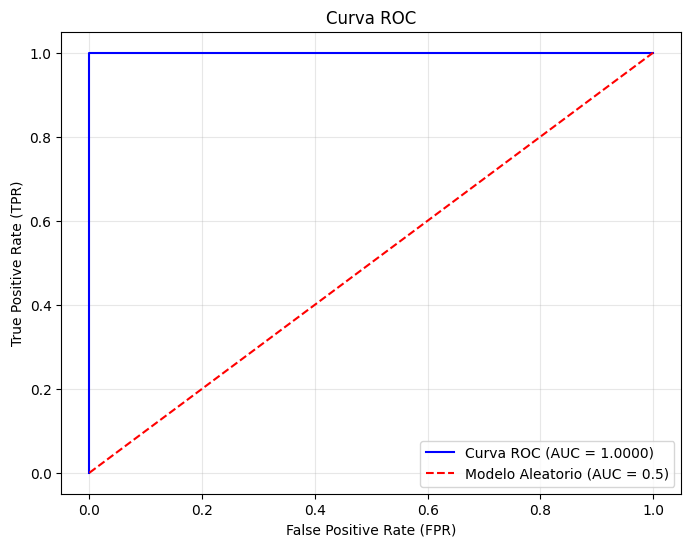


RESPUESTA
- El modelo es 'bueno' tirando a 'excelente', ya que tiene un AUC de 1.0000.
- Según la tabla de referencia de los apuntes, al estar en el rango de
  0.8-0.9 se considera un buen modelo para distinguir entre clases.


In [38]:
# Datos del modelo (NO modificar)
y_real =  np.array([0, 1, 0, 1, 1, 0, 1, 0, 0, 1])
y_proba = np.array([0.15, 0.85, 0.25, 0.78, 0.92, 0.30, 0.88, 0.10, 0.45, 0.70])

# --- Paso 1: Calcular fpr, tpr, thresholds ---
# Tu código aquí
fpr, tpr, thresholds = roc_curve(y_real, y_proba)
print(f"\n{turquesa}FPR:{reset}{magenta} {fpr}{reset}")
print(f"{turquesa}TPR:{reset}{magenta} {tpr}{reset}")
print(f"{turquesa}Thresholds:{reset}{magenta} {thresholds}{reset}")

# --- Paso 2: Calcular AUC ---
# Tu código aquí
auc_score = roc_auc_score(y_real, y_proba)
print(f"\n{turquesa}AUC:{reset}{magenta} {auc_score:.4f}{reset}")

# --- Paso 3: Dibujar la curva ROC ---
# Tu código aquí
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Modelo Aleatorio (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# --- Paso 4: Responde ---
print(f"{azul}\nRESPUESTA{reset}")
print(f"{lima}- El modelo es 'bueno' tirando a 'excelente', ya que tiene un AUC de {auc_score:.4f}.")
print(f"- Según la tabla de referencia de los apuntes, al estar en el rango de")
print(f"  0.8-0.9 se considera un buen modelo para distinguir entre clases.{reset}")

## 🔴 Ejercicio 9: Métricas de regresión — MAE, RMSE y R²

En este ejercicio vas a calcular e interpretar las tres métricas principales de regresión.

**Contexto:** Un modelo predice el precio de viviendas (en miles de euros). Abajo tienes los precios reales y los predichos para 8 viviendas.

**Pasos a seguir:**

1. Calcula el **MAE** (Mean Absolute Error) usando `mean_absolute_error`. Imprímelo con la frase: `"MAE = X.XX miles de euros -> En promedio, el modelo se equivoca en X.XX miles de euros"`.
2. Calcula el **RMSE** (Root Mean Squared Error). Para ello, calcula primero el MSE con `mean_squared_error` y después aplica `np.sqrt()`. Imprímelo con la frase: `"RMSE = X.XX miles de euros"`.
3. Calcula el **R²** con `r2_score`. Imprímelo con la frase: `"R² = X.XX -> El modelo explica el XX% de la variabilidad de los precios"`.
4. **Responde**: ¿Por qué el RMSE es mayor que el MAE? ¿Qué nos dice eso sobre los errores del modelo? Pista: fíjate en la vivienda 7 (precio real: 480, predicho: 420).

In [41]:
# Precios de viviendas en miles de € (NO modificar)
y_real = np.array([200, 350, 150, 420, 300, 180, 480, 275])
y_pred = np.array([210, 330, 160, 400, 310, 175, 420, 260])

# --- Paso 1: MAE ---
# Tu código aquí
mae = mean_absolute_error(y_real, y_pred)
print(f"\n{turquesa}MAE = {mae:.2f} miles de euros -->{reset}{magenta} En promedio, el modelo se equivoca en {mae:.2f} miles de euros{reset}")

# --- Paso 2: RMSE ---
# Tu código aquí
mse = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)
print(f"{turquesa}RMSE ={reset}{magenta} {rmse:.2f} miles de euros{reset}")

# --- Paso 3: R² ---
# Tu código aquí
r2 = r2_score(y_real, y_pred)
print(f"{turquesa}R2 = {r2:.2f} -->{reset}{magenta} El modelo explica el {r2*100:.0f}% de la variabilidad de los precios{reset}")

# --- Paso 4: Responde ---
print(f"{azul}\nRESPUESTA{reset}")
print(f"{lima}- El RMSE es mayor que el MAE porque al elevar los errores al cuadrado antes de la")
print(f"  media, penaliza mucho más las desviaciones grandes.")
print(f"- Esto nos dice que el modelo tiene algunos errores considerables (como en la ")
print(f"  vivienda 7), y el RMSE refleja mejor esa falta de robustez ante valores atípicos.{reset}")


MAE = 18.75 miles de euros --> En promedio, el modelo se equivoca en 18.75 miles de euros
RMSE = 24.87 miles de euros
R2 = 0.95 --> El modelo explica el 95% de la variabilidad de los precios

RESPUESTA
- El RMSE es mayor que el MAE porque al elevar los errores al cuadrado antes de la
  media, penaliza mucho más las desviaciones grandes.
- Esto nos dice que el modelo tiene algunos errores considerables (como en la 
  vivienda 7), y el RMSE refleja mejor esa falta de robustez ante valores atípicos.


## 🔴 Ejercicio 10: Elegir la métrica correcta según el caso de negocio

En este ejercicio final vas a aplicar todo lo aprendido para elegir la métrica adecuada en diferentes escenarios reales.

**Para cada caso de negocio**, responde a estas 3 preguntas:
- **a)** ¿Qué tipo de error es más grave: un falso positivo (FP) o un falso negativo (FN)?
- **b)** ¿Qué métrica usarías como métrica principal? Elige entre: Accuracy, Precision, Recall, F1, ROC-AUC, MAE, RMSE, R².
- **c)** Justifica tu elección en 1-2 frases.

---

**Caso 1 — Diagnóstico de cáncer:** Un modelo predice si un paciente tiene cáncer (positivo) o no (negativo). El hospital quiere detectar **todos** los casos posibles, aunque eso genere algunas falsas alarmas.

**Caso 2 — Filtro de spam:** Un modelo clasifica correos como spam (positivo) o legítimo (negativo). Que un spam pase no es grave, pero **perder un correo legítimo** marcándolo como spam sí es un problema serio.

**Caso 3 — Predicción de temperatura:** Un modelo meteorológico predice la temperatura máxima diaria en grados Celsius. Quieres saber cuánto se equivoca de media.

**Caso 4 — Detección de fraude bancario:** Un modelo clasifica transacciones como fraudulentas (positivo) o legítimas (negativo). El dataset tiene 99.5% de transacciones legítimas y 0.5% de fraudes.

In [53]:
# Responde aquí a los 4 casos con print()

print(f"\n{turquesa}CASO 1 — DIAGNÓSTICO DE CÁNCER{reset}")
print(f"{azul}  a) Más grave:{reset}{magenta} FN (un enfermo sin detectar).{reset}")
print(f"{azul}  b) Métrica:{reset}{magenta} Recall.{reset}")
print(f"{azul}  c) Justificación:{reset}{magenta} El hospital quiere detectar todos los casos posibles; un FN") 
print(f"     significa no tratar a un paciente grave.{reset}")

print(f"\n{turquesa}CASO 2 — FILTRO DE SPAM{reset}")
print(f"{azul}  a) Más grave:{reset}{magenta} FP (correo legítimo a la carpeta de spam).{reset}")
print(f"{azul}  b) Métrica:{reset}{magenta} Precision.{reset}")
print(f"{azul}  c) Justificación:{reset}{magenta} Es preferible que pase un spam a que el usuario pierda un")
print(f"     correo importante de trabajo o personal.{reset}")

print(f"\n{turquesa}CASO 3 — PREDICCIÓN DE TEMPERATURA{reset}")
print(f"{azul}  a) Más grave:{reset}{magenta} Ambos errores son similares en importancia.{reset}")
print(f"{azul}  b) Métrica:{reset}{magenta} MAE.{reset}")
print(f"{azul}  c) Justificación:{reset}{magenta} Queremos saber cuánto se equivoca de media de forma intuitiva") 
print(f"     en grados Celsius.{reset}")

print(f"{turquesa}\nCASO 4 — DETECCIÓN DE FRAUDE BANCARIO{reset}")
print(f"{azul}  a) Más grave:{reset}{magenta} FN (no detectar un fraude).{reset}")
print(f"{azul}  b) Métrica:{reset}{magenta} F1-Score o ROC-AUC.{reset}")
print(f"{azul}  c) Justificación:{reset}{magenta} Al estar el dataset tan desbalanceado (0.5% fraudes), el Accuracy")
print(f"     no sirve y necesitamos un balance entre detectar fraudes y no bloquear tarjetas") 
print(f"     legítimas.{reset}")


CASO 1 — DIAGNÓSTICO DE CÁNCER
  a) Más grave: FN (un enfermo sin detectar).
  b) Métrica: Recall.
  c) Justificación: El hospital quiere detectar todos los casos posibles; un FN
     significa no tratar a un paciente grave.

CASO 2 — FILTRO DE SPAM
  a) Más grave: FP (correo legítimo a la carpeta de spam).
  b) Métrica: Precision.
  c) Justificación: Es preferible que pase un spam a que el usuario pierda un
     correo importante de trabajo o personal.

CASO 3 — PREDICCIÓN DE TEMPERATURA
  a) Más grave: Ambos errores son similares en importancia.
  b) Métrica: MAE.
  c) Justificación: Queremos saber cuánto se equivoca de media de forma intuitiva
     en grados Celsius.

CASO 4 — DETECCIÓN DE FRAUDE BANCARIO
  a) Más grave: FN (no detectar un fraude).
  b) Métrica: F1-Score o ROC-AUC.
  c) Justificación: Al estar el dataset tan desbalanceado (0.5% fraudes), el Accuracy
     no sirve y necesitamos un balance entre detectar fraudes y no bloquear tarjetas
     legítimas.


---

## Resumen de Conceptos Clave (Capítulos 3.3 y 3.4)

### Cap. 3.3 — Validación y Generalización
| Concepto | Descripción |
|----------|-------------|
| **Overfitting** | Train alto, test bajo. El modelo memoriza en vez de aprender |
| **Underfitting** | Train bajo, test bajo. El modelo es demasiado simple |
| **Stratify** | Mantiene las proporciones de clases al dividir datos |
| **Pipeline** | Encapsula preprocesamiento + modelo para evitar data leakage |
| **Cross-Validation** | Evalúa el modelo en múltiples splits (K-Fold). Reporta media +/- std |
| **GridSearchCV** | Busca el mejor hiperparámetro combinando grid + cross-validation |

### Cap. 3.4 — Métricas de Evaluación
| Métrica | Fórmula / Uso |
|---------|---------------|
| **Accuracy** | Aciertos / Total. Solo fiable con clases balanceadas |
| **Precision** | TP / (TP + FP). Prioriza cuando los FP son costosos |
| **Recall** | TP / (TP + FN). Prioriza cuando los FN son inaceptables |
| **F1-Score** | Media armónica de Precision y Recall |
| **ROC-AUC** | Evalúa el modelo en todos los thresholds. AUC > 0.9 = excelente |
| **MAE** | Error absoluto medio. Robusto a outliers |
| **RMSE** | Raíz del error cuadrático medio. Penaliza errores grandes |
| **R²** | Porcentaje de variabilidad explicada. 1.0 = perfecto, 0 = como la media |